In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from moabb.paradigms import P300,LeftRightImagery, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = LeftRightImagery(resample=250)
dataset = Zhou2016()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[2],
     return_epochs=True
)
session = meta['session'].unique()[-1]
#session ='4test'
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


Reading 0 ... 227539  =      0.000 ...   910.156 secs...


/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:102: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])


Reading 0 ... 216079  =      0.000 ...   864.316 secs...


/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:102: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])


Reading 0 ... 213939  =      0.000 ...   855.756 secs...


...

/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:186: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)
/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:186: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)
/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:186: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
40 matching events found
No baseline correction applied
Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
50 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:186: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)
/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:186: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
50 matching events found
No baseline correction applied
Not setting metadata
290 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:186: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [13]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import stf_tensor
from mne.decoding import Scaler

X = epochs.get_data()
X = Scaler(scalings='mean', with_mean=True).fit_transform(X)
X = stf_tensor(X, sfreq=epochs.info['sfreq'], zscore=True)
X = tl.tensor(X)
y = labels
X.shape

/tmp/ipykernel_1414/705532774.py:7: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(100, 14, 16, 80)

In [14]:
import numpy as np
np.any(X==0)

array(False)

In [15]:
%env PYTHONWARNINGS=ignore::FutureWarning

env: PYTHONWARNINGS=ignore::FutureWarning


In [39]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFwe
from hoda.classification import SelectF

clf = make_pipeline(
    SelectF(alpha=.05),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=3,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,#(1,),
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
    ),
    rank_grid=[1],
    verbose=True,
    extra_train_info=True,
    n_jobs=1,
    cv= StratifiedKFold(random_state=42,shuffle=True),
    truncate=True,
    clf=clf,
)
bttda.fit(X,y, test=True)

Model selection block 1/3...

Trying rank 1	score: 0.6571

Selected rank 1 with score 0.6571
New ranks: [1]


Model selection block 2/3...

Trying rank 1	score: 0.6383

Selected rank 1 with score 0.6383
New ranks: [1, 1]


Model selection block 3/3...

Trying rank 1	score: 0.6894

Selected rank 1 with score 0.6894
New ranks: [1, 1, 1]


Fitting block 1/3...
Fitting block 2/3...
Fitting block 3/3...


GreedyBTTDA(clf=Pipeline(steps=[('selectf', SelectF(alpha=0.05)),
                                ('functiontransformer',
                                 FunctionTransformer(func=<function CupyBackend.to_numpy at 0x7fc792f84b80>)),
                                ('standardscaler', StandardScaler()),
                                ('lineardiscriminantanalysis',
                                 LinearDiscriminantAnalysis(shrinkage='auto',
                                                            solver='lsqr'))]),
            cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
            extra_train_info=True,
            hoda_params={'delta': None, 'extra_train_info': False,
                         'init': 'random', 'max_iter': 128, 'obj': 'tr',
                         'random_state': 42, 'rank': 1, 'shrinkage': 'lw',
                         'solver': 'lanczos', 'taper': False, 'toeplitz': None,
                         'tol': 1e-08, 'verbose': False},
            max_blocks=3, n_jobs=1, rank_grid=[1], verbose=True)

In [46]:
bttda.model_select_info_.groupby(['block', 'rank']).val_score.aggregate('mean')

block  rank
0      1       0.657143
1      1       0.638294
2      1       0.689385
Name: val_score, dtype: float64

In [47]:
Xt = bttda.transform(X)

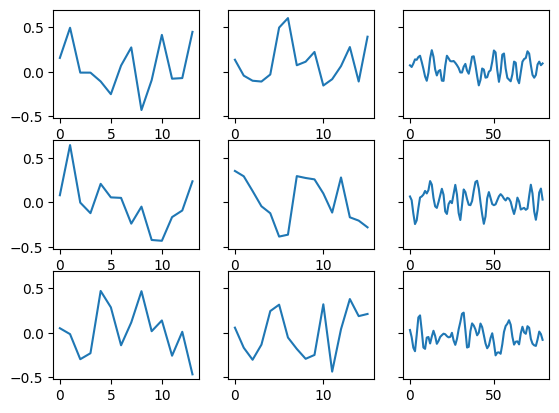

In [48]:
fig, axs = plt.subplots(bttda.n_blocks_,3, sharey=True)
for b,block in enumerate(bttda.blocks_):
    for k in range(3):
        axs[b,k].plot(tl.to_numpy(block.weights_[k]))



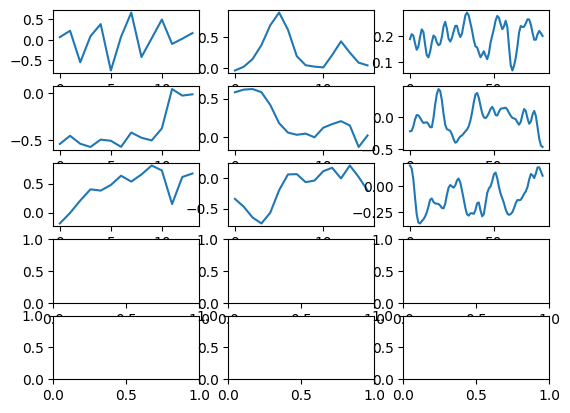

In [49]:
fig, axs = plt.subplots(5,3, sharey=False)
for b,block in enumerate(bttda.blocks_[:5]):
    for k in range(3):
        axs[b,k].plot(tl.to_numpy(block.aps_[k]))

block  rank  n_features
0      2     1             0.956944
1      2     1             0.956944
2      2     1             0.956944
3      3     1             0.956944
Name: val_score, dtype: float64

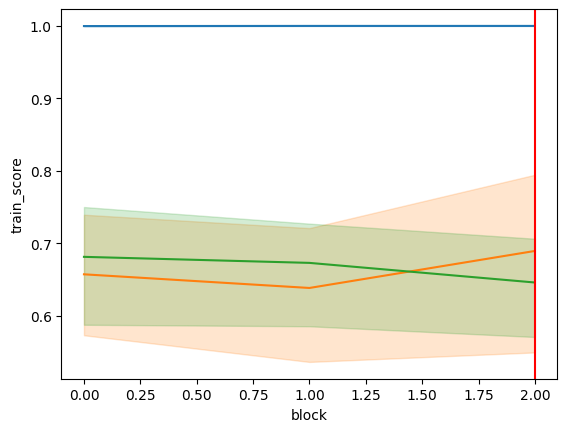

In [50]:
import seaborn as sns 
import matplotlib.pyplot as plt
df_select = bttda.model_select_info_best_
plt.style.use('default')
sns.lineplot(data=df_select, x='block',y='train_score')
sns.lineplot(data=df_select, x='block',y='val_score')
sns.lineplot(data=df_select, x='block',y='test_score')

plt.axvline(bttda.n_blocks_-1, color='red')

<Axes: xlabel='block', ylabel='nmse'>

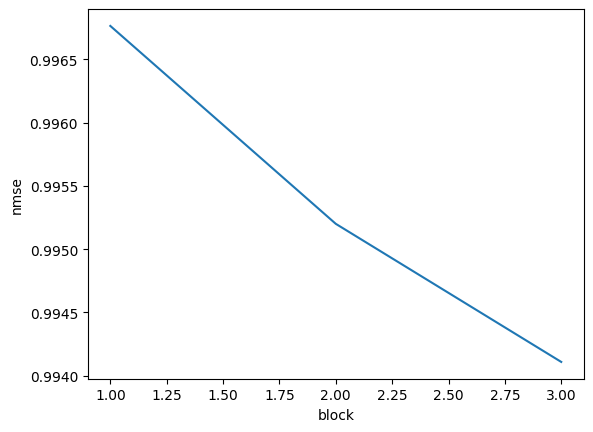

In [51]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.lineplot(data=bttda.train_info_, x='block',y='nmse')